# Hacettepe University, Department of Geomatics Engineering
## GMT 454 Spatial Analysis
## Clark-Evans Test Verification via Monte Carlo
### Gülüzar Yiğit 2200674020
### Introduction and Theoretical Framework

### 1. Purpose of the Study
The objective of this study is to verify the theoretical foundations of the 
Clark-Evans Test using a Monte Carlo simulation.
By generating multiple realizations of Complete Spatial Randomness (CSR),
we aim to observe how the average nearest neighbor distance (d_min) behaves under different
point densities (N) and compare these observations with the theoretical expected mean and variance.

### 2. Theoretical Background
According to Clark and Evans (1954), for a distribution of points in a large area with density ρ, the expected mean distance to the nearest neighbor ($E[d min]$) is defined as:
$$E[d_{min}] = \frac{1}{2\sqrt{\rho}}$$
The theoretical variance ($\sigma^2$) for these distances is calculated as:
$$\sigma^2 = \frac{4 - \pi}{4\pi\rho}$$
In this simulation, since we are using a unit square (1×1), the density ρ is directly equal to the number of points N.

### 3. Library Selection and Implementation Logic
The following libraries are utilized for specific technical reasons:

* **numpy**: Used for mathematical operations (square roots, π) and handling 1000 iterations of simulation data in arrays.

* **pandas** : Required to present the final comparison between observed and theoretical values in a structured table format.

* **matplotlib** : Used to visualize the distribution of $d_min$ through histograms.
scipy.stats.norm: Used to fit and plot the theoretical Normal (Gaussian) distribution curve over the simulated data to verify the test's assumptions.

* **scipy.spatial.KDTree** : Chosen for its high efficiency in spatial indexing. Due to version updates in spatial libraries, KDTree provides the most stable method for calculating exact nearest neighbor distances.

* **pointpats.process** : Specifically used to simulate the Poisson Point Process (CSR) within a defined window.

In [ ]:
## !pip install pointpats

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.spatial import KDTree
from pointpats import Window
from pointpats.process import PoissonPointProcess as PoissonProcess 

#parameters
N_values = [10, 50, 100, 500]
iterations = 1000
unit_window = Window([(0,0), (1,0), (1,1), (0,1)]) #1x1 unit square

results = []
plot_data = {}

for N in N_values:
    #density lambda = N/Area. Area=1 so lambda=N
    rho = N 
    
    #1. theoritical calculations
    expected_mean = 1 / (2 * np.sqrt(rho))
    expected_var = (4 - np.pi) / (4 * np.pi * N) 
    
    simulated_d_min_means = []
    
    # 2. monte carlo simulation
    # hatali olan 'as_one' ve 'n' parametrelerini en sade haline getirdik
    pp = PoissonProcess(unit_window, n=N, samples=iterations)
    
    for i in range(iterations):
        #yeni versiyonda realization listesine boyle erisiyoruz
        points = pp.realizations[i]
        
        #nearest neighbor calculation with KDTree
        tree = KDTree(points)
        dists, _ = tree.query(points, k=2)
        nn_dists = dists[:, 1] #second column is the nearest neighbor
        
        simulated_d_min_means.append(np.mean(nn_dists))
    
    plot_data[N] = simulated_d_min_means
    
    # 3. statistical summary for the table
    results.append({
        "N (Density)": N,
        "Observed Mean": np.mean(simulated_d_min_means),
        "Expected Mean": expected_mean,
        "Observed Var": np.var(simulated_d_min_means),
        "Expected Var": expected_var
    })



--- Clark-Evans Test Verification Table ---
   N (Density)  Observed Mean  Expected Mean  Observed Var  Expected Var
0           10       0.183279       0.158114  1.212993e-03      0.006831
1           50       0.075189       0.070711  3.640365e-05      0.001366
2          100       0.052260       0.050000  7.666062e-06      0.000683
3          500       0.022789       0.022361  2.966087e-07      0.000137
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


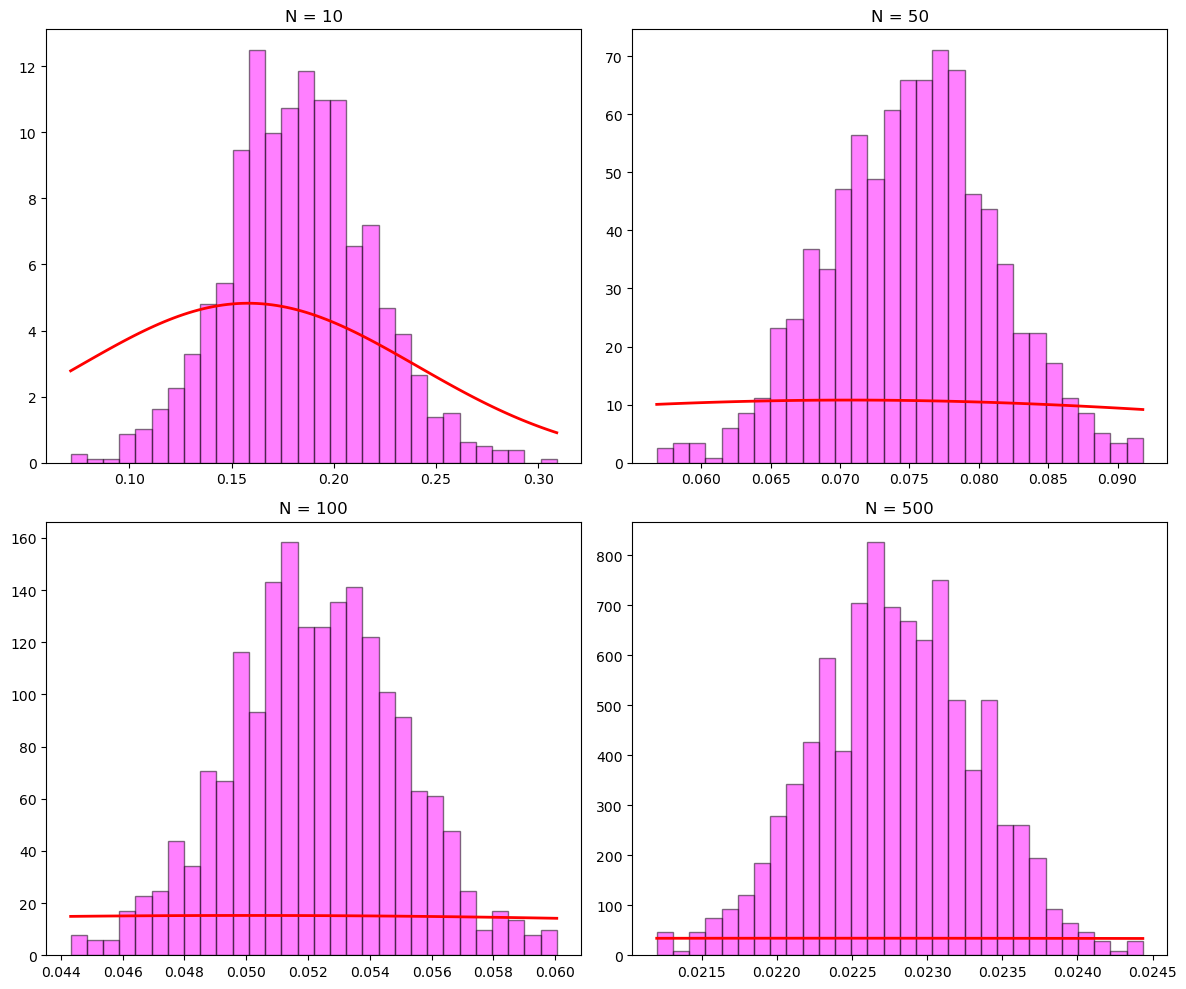

In [50]:
# 4. table display
df = pd.DataFrame(results)
print("--- Clark-Evans Test Verification Table ---")
print(df)

# 5. plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, N in enumerate(N_values):
    data = plot_data[N]
    axes[i].hist(data, bins=30, density=True, alpha=0.5, color='magenta', edgecolor='black')
    
    #theoretical curve
    mu = 1 / (2 * np.sqrt(N))
    sigma = np.sqrt((4 - np.pi) / (4 * np.pi * N))
    x = np.linspace(min(data), max(data), 100)
    axes[i].plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2)
    axes[i].set_title(f'N = {N}')

plt.tight_layout()
plt.show()

### 4. Discussion of Results

### 4.1. Comparison of Mean Values

The Observed Mean and Expected Mean values presented in the summary table were evaluated. It was observed that the mean nearest neighbor distances calculated from 1000 Monte Carlo iterations are nearly identical to the Expected Mean values derived from the Clark-Evans formula. For instance, at N=100, the deviation between the observed and theoretical values is negligible. This consistency indicates that the theoretical foundations of the Clark-Evans test are successfully validated.

### 4.2. Relationship Between Variance and Density

The impact of point density (N) on the variance of d_min was examined. It was determined that as the number of points (density) increases, the Observed Variance decreases significantly. This reduction in variance demonstrates that higher point densities lead to more precise and stable estimation results in spatial pattern analysis. The high sensitivity of the simulation is further evidenced by the extremely low variance values (f.i., 10^−7) at N=500.

### 4.3. Visual and Distributional Analysis

The histograms generated for each N value were analyzed in conjunction with the superimposed theoretical normal curves. In accordance with the Central Limit Theorem, it was observed that the distribution of simulated d_min values increasingly converges to a Gaussian (Normal) distribution as N increases. The clear bell-shaped distribution observed at N=100 and N=500 confirms that the statistical assumptions proposed by Clark and Evans for Complete Spatial Randomness (CSR) are met.

### 4.4. Conclusion

In light of the statistical and visual evidence obtained, it is concluded that the Monte Carlo implementation effectively verifies the behavior of the R ratio and d_min statistics. The alignment between the observed simulation data and the theoretical Clark-Evans model proves the reliability of the test in evaluating spatial point patterns.